# Fase 2 — Historia propia y calendario

**Pregunta:** ¿qué historia distrital existe en el origen de los pronósticos a 2 y 4 semanas, y cómo se compara una media causal corta con la persistencia? El calendario del objetivo se conoce de antemano.

Las comparaciones siguientes son reglas descriptivas, no resultados de XGBoost. Se usa `casos_Dengue` como conteo observado; la definición oficial de brote sigue pendiente. La disponibilidad de publicación real no está registrada por semana, por lo que se supone provisionalmente que cada valor está disponible al cierre de su semana.

In [1]:
import sys
from pathlib import Path
ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(ROOT))

import json
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from src.eda.carga import cargar_integrado
from src.eda.temporal import asignar_temporada, prediccion_estacional
from src.modeling.historia_calendario import construir_historia_calendario
from src.utils.paths import DOCS, SILVER_INTEGRADO
from src.validation.expectations_integrado import coverage_path, load_case_coverage, validate_complete

SALIDA = DOCS / "feature_engineering"
METRICAS = SALIDA / "metricas"
FIGURAS = SALIDA / "figuras" / "fase2_historia_calendario"
METRICAS.mkdir(parents=True, exist_ok=True)
FIGURAS.mkdir(parents=True, exist_ok=True)

## 1. Verificación del panel y construcción causal

Cada fila es una semana **objetivo** `t`. Para horizonte `h`, `casos_lag_h` usa `t−h`; `casos_lag_(h+1)` usa la semana anterior al origen. La media y el conteo de semanas positivas cubren las cuatro semanas que terminan en `t−h`. No se rellenan las primeras filas sin historia. `semana_epi_seno` y `semana_epi_coseno` dependen solo del calendario conocido. La semana 53 comparte posición circular con la semana 1.

In [2]:
df = cargar_integrado()
cobertura = load_case_coverage(coverage_path(SILVER_INTEGRADO))
validate_complete(df, cobertura)
features = {h: construir_historia_calendario(df, h, ventana=4) for h in (2, 4)}
for h, f in features.items():
    assert len(f) == len(df)
    assert f[["ubigeo", "anio", "semana"]].equals(df[["ubigeo", "anio", "semana"]])
    assert not f.duplicated(["ubigeo", "anio", "semana"]).any()

cobertura_features = {
    str(h): {
        "filas": len(f),
        "con_lag_origen": int(f[f"casos_lag_{h}"].notna().sum()),
        "con_media_4": int(f[f"casos_media_4_h{h}"].notna().sum()),
        "sin_historia_media_4": int(f[f"casos_media_4_h{h}"].isna().sum()),
    } for h, f in features.items()
}
print(json.dumps(cobertura_features, indent=2))
features[4].loc[(features[4].ubigeo == "200101") &
    (features[4].anio == 2025) & (features[4].semana == 52)].T

{
  "2": {
    "filas": 30485,
    "con_lag_origen": 30355,
    "con_media_4": 30160,
    "sin_historia_media_4": 325
  },
  "4": {
    "filas": 30485,
    "con_lag_origen": 30225,
    "con_media_4": 30030,
    "sin_historia_media_4": 455
  }
}


,468
ubigeo,200101
anio,2025
semana,52
semana_inicio,2025-12-21 00:00:00
origen_inicio,2025-11-23 00:00:00
origen_cierre,2025-11-29 00:00:00
casos_lag_4,1.0
casos_lag_5,1.0
casos_media_4_h4,0.75
casos_semanas_positivas_4_h4,3.0


## 2. Comparación de reglas simples en las mismas filas

Se compara la persistencia `casos(t−h)`, la media aritmética de las cuatro semanas disponibles y el valor de la misma semana epidemiológica del año anterior. El error es `|log1p(real)−log1p(predicho)|` y todas las reglas se miden sobre **las mismas filas** para cada horizonte. El comparador estacional reutiliza la alineación por año/semana del EDA, incluida la semana 53. Se reportan años y temporadas para revelar variación de régimen. Una menor MAE de una regla simple no demuestra que su variable mejore XGBoost.

In [3]:
estacional = prediccion_estacional(df, "casos_Dengue")
temporada = asignar_temporada(df.anio, df.semana, semana_inicio=35)
metricas_h = {}
filas_detalle = []
for h, f in features.items():
    pred = {
        "persistencia": f[f"casos_lag_{h}"],
        "media_4": f[f"casos_media_4_h{h}"],
        "estacional": estacional,
    }
    comun = pd.concat(pred, axis=1).notna().all(axis=1)
    assert comun.sum() > 0
    metricas_h[str(h)] = {
        "filas_comunes": int(comun.sum()),
        "mae_log1p_global": {},
        "mae_log1p_por_anio": {},
        "mae_log1p_por_temporada": {},
    }
    for nombre, p in pred.items():
        error = (np.log1p(df.casos_Dengue) - np.log1p(p)).abs()
        global_ = float(error[comun].mean())
        anio = {str(k): float(v) for k, v in error[comun].groupby(df.loc[comun, "anio"]).mean().items()}
        temp = {str(k): float(v) for k, v in error[comun].groupby(temporada[comun]).mean().items()}
        metricas_h[str(h)]["mae_log1p_global"][nombre] = round(global_, 4)
        metricas_h[str(h)]["mae_log1p_por_anio"][nombre] = {k: round(v, 4) for k, v in anio.items()}
        metricas_h[str(h)]["mae_log1p_por_temporada"][nombre] = {k: round(v, 4) for k, v in temp.items()}
        filas_detalle.append({"horizonte": h, "regla": nombre, "filas": int(comun.sum()),
            "mae_log1p": round(global_, 4)})
comparacion = pd.DataFrame(filas_detalle)
comparacion

,horizonte,regla,filas,mae_log1p
0,2,persistencia,27105,0.1650
1,2,media_4,27105,0.1867
2,2,estacional,27105,0.5254
3,4,persistencia,27105,0.2084
4,4,media_4,27105,0.2326
5,4,estacional,27105,0.5254


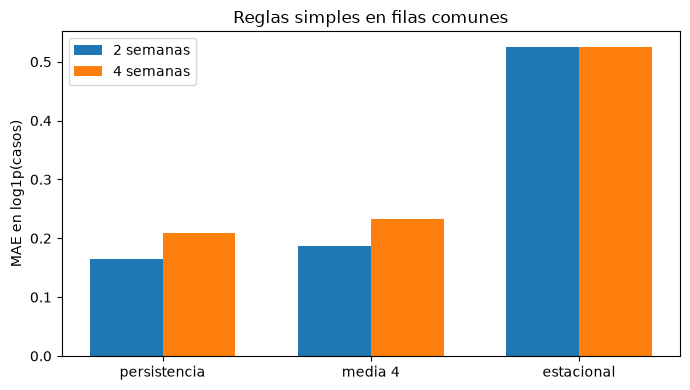

In [4]:
fig, ax = plt.subplots(figsize=(7, 4))
for i, (h, grupo) in enumerate(comparacion.groupby("horizonte")):
    ax.bar(np.arange(3) + (i - .5) * .35, grupo.mae_log1p.to_numpy(), width=.35,
           label=f"{h} semanas")
ax.set_xticks(np.arange(3), ["persistencia", "media 4", "estacional"])
ax.set(ylabel="MAE en log1p(casos)", title="Reglas simples en filas comunes")
ax.legend()
fig.tight_layout()
fig.savefig(FIGURAS / "01_reglas_por_horizonte.png", dpi=160)
plt.show()

## 3. Registro y límites

Las métricas se guardan en `docs/`; no se escribe en `data/gold/`. La comparación usa todo el panel para **describir** las reglas; no selecciona hiperparámetros ni calcula climatologías aprendidas. Para un resultado predictivo de XGBoost harán falta cortes temporales, ajuste dentro de cada fold y la decisión sobre el objetivo. Los ceros históricos sin notificación explícita y la latencia de publicación siguen siendo límites.

In [5]:
resultado = {
    "entrada": str(SILVER_INTEGRADO.relative_to(ROOT)),
    "filas_panel": len(df),
    "horizontes": [2, 4],
    "ventana_historia": 4,
    "cobertura_features": cobertura_features,
    "comparacion_reglas": metricas_h,
    "convenciones": {
        "fila": "semana objetivo",
        "ultimo_caso_admisible": "semana t-h, sujeto a publicación efectiva",
        "semana_53": "misma posición circular que semana 1",
        "fecha_publicacion_semanal": "no disponible; se supone cierre de semana solo para auditoría",
        "objetivo": "casos_Dengue; definición de brote pendiente",
    },
}
archivo = METRICAS / "fase2_historia_calendario.json"
archivo.write_text(json.dumps(resultado, ensure_ascii=False, indent=2) + "\n", encoding="utf-8")
print("Métricas guardadas:", archivo)

Métricas guardadas: C:\Users\Rosa\RufoEsEternoElRegreso\Denguekay\docs\feature_engineering\metricas\fase2_historia_calendario.json
